## Probabilistic PCA with ARD for AML / ALL / Normal Classification


## Table of Contents

1. [Introduction](#introduction)  
2. [Environment Setup & Packages](#environment-setup-packages)  
3. [Data Loading & Preprocessing](#data-loading-preprocessing)  
4. [Model Definition: PPCA with ARD](#model-definition-ppca-with-ard)  
5. [Inference Setup](#inference-setup)  
6. [Model Training](#model-training)  
7. [Evaluation & Classification](#evaluation-classification)  
8. [Results & Visualization](#results-visualization)  
9. [Conclusion & Future Work](#conclusion-future-work)  


<!-- Anchor for Introduction -->
<a id="introduction"></a>
## 1. Introduction

_An end-to-end implementation of Probabilistic PCA using Automatic Relevance Determination priors, trained via Stochastic Variational Inference on gene expression data to distinguish between Acute Myeloid Leukemia (AML), Acute Lymphoblastic Leukemia (ALL), and normal samples._


<!-- Anchor for Environment Setup -->
<a id="environment-setup-packages"></a>
## 2. Environment Setup & Packages

Before diving into the model implementation, we load all of the libraries and modules we’ll need throughout this notebook.


In [1]:
# ─────────────── Timing Utilities ───────────────
import time                   # time.sleep, performance measurement

# ─────────────── Data Handling ────────────────
import pandas as pd           # pd.read_csv, DataFrame operations
import numpy as np            # np.random.seed, array operations

# ─────────────── Deep Learning & Probabilistic Programming ───────────────
import torch                  # torch.Tensor, torch.nn.Module, torch.optim
import pyro                   # pyro.set_rng_seed, framework entry point
import pyro.distributions as dist      # probability distributions (Normal, Gamma, etc.)
from pyro.infer import SVI, Trace_ELBO # variational inference API
from pyro.optim import ClippedAdam, Adam  # optimizers with (optional) gradient clipping

# ─────────────── Visualization ───────────────
import matplotlib.pyplot as plt  # plt.subplots, plt.plot, plt.show
import seaborn as sns            # sns.set_style, sns.scatterplot, statistical plots

# ─────────────── Evaluation & Manifold Learning ───────────────
from sklearn.metrics import confusion_matrix  # compute classification confusion matrix
from sklearn.manifold import TSNE            # t-SNE for latent-space visualization

# ─────────────── Random Seeds ───────────────
# Set global seeds for reproducibility
np.random.seed(0)
torch.manual_seed(0)
pyro.set_rng_seed(0)


c:\Users\juliu\anaconda3\envs\GEGE\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<!-- Anchor for Environment Setup -->
<a id="data-loading-preprocessing"></a>
## 3. Loading of Training and Validation Data

Before diving into the model implementation, we load all of the libraries and modules we’ll need throughout this notebook.


In [ ]:
# load the data
test_data_path = "small_test_data.csv"
test_label_path = "small_test_labels.csv"
test_data = pd.read_csv(test_data_path).values.astype(np.float32)
test_label = pd.read_csv(test_label_path).values

val_data_path = "small_val_data.csv"
val_label_path = "small_val_labels.csv"
val_data = pd.read_csv(val_data_path).values.astype(np.float32)
val_label = pd.read_csv(val_label_path).values

print("test_data shape:", test_data.shape)
print("test_label shape:", test_label.shape)

print(test_data[0,0:10])

def normalize_data(data):
    # Z-score normalization per gene
    X_train_mean = data.mean(axis=0)
    X_train_std = data.std(axis=0) + 1e-6  # avoid div-by-zero
    X_norm = (data - X_train_mean) / X_train_std
    X_clipped = np.clip(X_norm, -10, 10)
    return X_clipped, X_train_mean, X_train_std

X_norm, X_train_mean, X_train_std = normalize_data(test_data)

X_train_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_train_tensor = torch.tensor(test_label, dtype=torch.long).flatten()

# --- 0) prepare X_val_tensor as before ---
X_val_norm    = (val_data - X_train_mean) / X_train_std
X_val_clipped = np.clip(X_val_norm, -10, 10)
X_val_tensor  = torch.tensor(X_val_clipped, dtype=torch.float32)
N_val         = X_val_tensor.shape[0]

test_data shape: (200, 400)
test_label shape: (200, 1)
[5.53000e-02 0.00000e+00 5.55492e+01 4.71580e+00 3.67360e+00 2.70879e+01
 1.88500e-01 1.50104e+01 1.45420e+01 1.54886e+01]


In [3]:
print(f"AML", np.sum(test_label == 0))
print(f"ALL", np.sum(test_label == 1))
print(f"Normal", np.sum(test_label == 2))

AML 118
ALL 67
Normal 15


In [5]:
def supervised_ppca_model_ard(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape

    # 1) ARD prior on α
    a0 = torch.tensor(1e-1)
    b0 = torch.tensor(1e-1)
    alpha = pyro.sample(
        "alpha",
        dist.Gamma(a0.expand(latent_dim),
                   b0.expand(latent_dim))
            .to_event(1)
    )

    # 2) ARD prior on W (no plates, event_dim=2)
    W = pyro.sample(
        "W",
        dist.Normal(
            torch.zeros(latent_dim, n_genes),
            alpha.unsqueeze(-1).rsqrt()
                 .expand(latent_dim, n_genes)
        ).to_event(2)
    )

    # 3) Bayesian softmax head priors
    A = pyro.sample(
        "A",
        dist.Normal(0., 1.)
            .expand([n_classes, latent_dim])
            .to_event(2)
    )
    b = pyro.sample(
        "b",
        dist.Normal(0., 1.)
            .expand([n_classes])
            .to_event(1)
    )

    # 4) Per-gene noise σ
    sigma = pyro.param("sigma_loc",
                       torch.full((n_genes,), 0.1),
                       constraint=dist.constraints.positive)

    # 5) Data plate
    with pyro.plate("data", n_samples):
        # latent codes z | α
        z = pyro.sample(
            "z",
            dist.Normal(0., alpha.rsqrt()).to_event(1)
        )

        # reconstruction
        x_loc = z @ W
        pyro.sample("obs",
                    dist.Normal(x_loc, sigma).to_event(1),
                    obs=X)

        # classification
        logits = z @ A.T + b
        pyro.sample("y",
                    dist.Categorical(logits=logits),
                    obs=y)


def supervised_ppca_guide_ard(X, y, latent_dim, n_classes):
    n_samples, n_genes = X.shape

    # 1) Variational posterior over α
    alpha_a = pyro.param("alpha_a",
                         torch.ones(latent_dim),
                         constraint=dist.constraints.positive)
    alpha_b = pyro.param("alpha_b",
                         torch.ones(latent_dim),
                         constraint=dist.constraints.positive)
    alpha = pyro.sample(
        "alpha",
        dist.Gamma(alpha_a, alpha_b).to_event(1)
    )

    # 2) Variational posterior q(W)
    w_loc   = pyro.param("w_loc",
                         torch.randn(latent_dim, n_genes))
    w_scale = pyro.param("w_scale",
                         torch.ones(latent_dim, n_genes),
                         constraint=dist.constraints.positive)
    pyro.sample(
        "W",
        dist.Normal(
            w_loc,
            (w_scale / alpha.unsqueeze(-1).sqrt())
               .expand(latent_dim, n_genes)
        ).to_event(2)
    )

    # 3) Variational posterior q(A), q(b)
    A_loc   = pyro.param("A_loc",
                         torch.randn(n_classes, latent_dim))
    A_scale = pyro.param("A_scale",
                         torch.ones(n_classes, latent_dim),
                         constraint=dist.constraints.positive)
    pyro.sample(
        "A",
        dist.Normal(A_loc, A_scale).to_event(2)
    )

    b_loc   = pyro.param("b_loc",
                         torch.zeros(n_classes))
    b_scale = pyro.param("b_scale",
                         torch.ones(n_classes),
                         constraint=dist.constraints.positive)
    pyro.sample(
        "b",
        dist.Normal(b_loc, b_scale).to_event(1)
    )

    # 4) Variational posterior q(z)
    z_loc   = pyro.param("z_loc",
                         torch.randn(n_samples, latent_dim))
    z_scale = pyro.param("z_scale",
                         torch.ones(n_samples, latent_dim),
                         constraint=dist.constraints.positive)
    with pyro.plate("data", n_samples):
        pyro.sample(
            "z",
            dist.Normal(z_loc,
                        z_scale / alpha.sqrt()).to_event(1)
        )


In [ ]:
latent_dim = 20
n_classes = 3

In [7]:
pyro.clear_param_store()

optimizer = ClippedAdam({
    "lr":          1e-2,
    "betas":       (0.9, 0.999),
    "weight_decay": 1e-4,   # <-- add this
})
svi = SVI(supervised_ppca_model_ard, supervised_ppca_guide_ard, optimizer, loss=Trace_ELBO())

start_time = time.time()

n_steps = 3500
for step in range(n_steps):
    loss = svi.step(X_train_tensor, y_train_tensor, latent_dim, n_classes)
    if step % 200 == 0:
        print(f"[Step {step}] Loss: {loss:.2f}")

# Total time spent
print(f"Total time spent: {time.time() - start_time:.2f} seconds")
print(f"Total time spent: {((time.time() - start_time) / 60):.2f} minutes")

[Step 0] Loss: 2822375163.55
[Step 200] Loss: 111052.46
[Step 400] Loss: 94230.69
[Step 600] Loss: 93329.22
[Step 800] Loss: 88184.71
[Step 1000] Loss: 86691.48
[Step 1200] Loss: 86269.28
[Step 1400] Loss: 84220.05
[Step 1600] Loss: 87863.46
[Step 1800] Loss: 84610.08
[Step 2000] Loss: 86613.17
[Step 2200] Loss: 86190.18
[Step 2400] Loss: 84397.75
[Step 2600] Loss: 86680.37
[Step 2800] Loss: 89473.18
[Step 3000] Loss: 84301.71
[Step 3200] Loss: 84268.77
[Step 3400] Loss: 84186.05
Total time spent: 37.55 seconds
Total time spent: 0.63 minutes


In [8]:
print(list(pyro.get_param_store().keys()))

['alpha_a', 'alpha_b', 'w_loc', 'w_scale', 'A_loc', 'A_scale', 'b_loc', 'b_scale', 'z_loc', 'z_scale', 'sigma_loc']


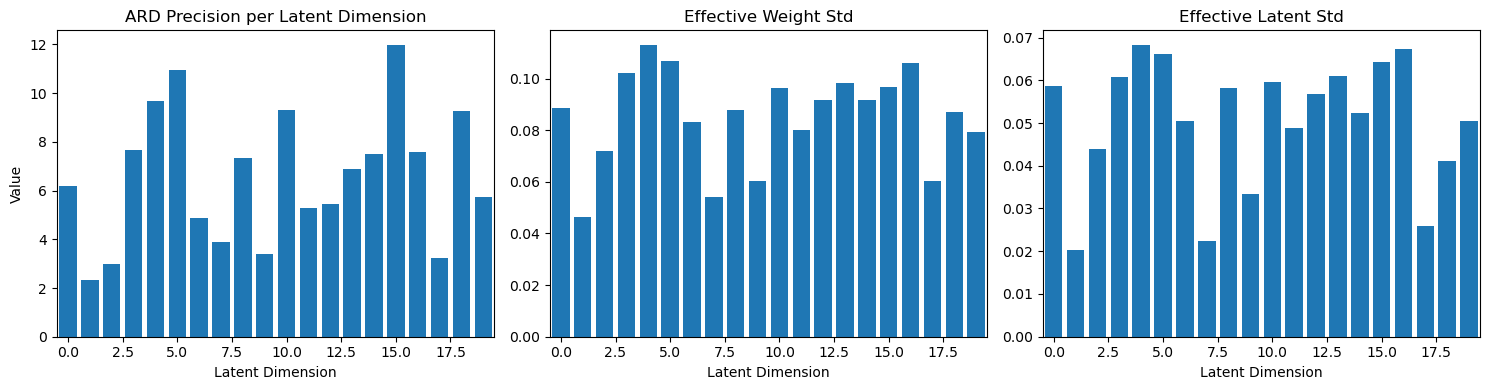

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 1) Pull in and compute your ARD precision means
alpha_a = pyro.param("alpha_a").detach().cpu().numpy()
alpha_b = pyro.param("alpha_b").detach().cpu().numpy()
alpha_mean = alpha_a / alpha_b
latent_dim = alpha_mean.shape[0]

# 2) Effective W std (average over genes)
w_scale    = pyro.param("w_scale").detach().cpu().numpy()
w_eff_mean = (w_scale / np.sqrt(alpha_mean[:, None])).mean(axis=1)

# 3) Effective z std (average over samples)
z_scale    = pyro.param("z_scale").detach().cpu().numpy()
z_eff_mean = (z_scale / np.sqrt(alpha_mean)).mean(axis=0)

# 4) Now plot—all variables are defined
x     = np.arange(latent_dim)
width = 0.8  # data‐unit width

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

axes[0].bar(x, alpha_mean,   width=width, align="center")
axes[0].set(title="ARD Precision per Latent Dimension", ylabel="Value")

axes[1].bar(x, w_eff_mean,   width=width, align="center")
axes[1].set(title="Effective Weight Std")

axes[2].bar(x, z_eff_mean,   width=width, align="center")
axes[2].set(title="Effective Latent Std")

for ax in axes:
    ax.set_xlabel("Latent Dimension")
    ax.set_xlim(-0.5, latent_dim - 0.5)

plt.tight_layout()
plt.show()

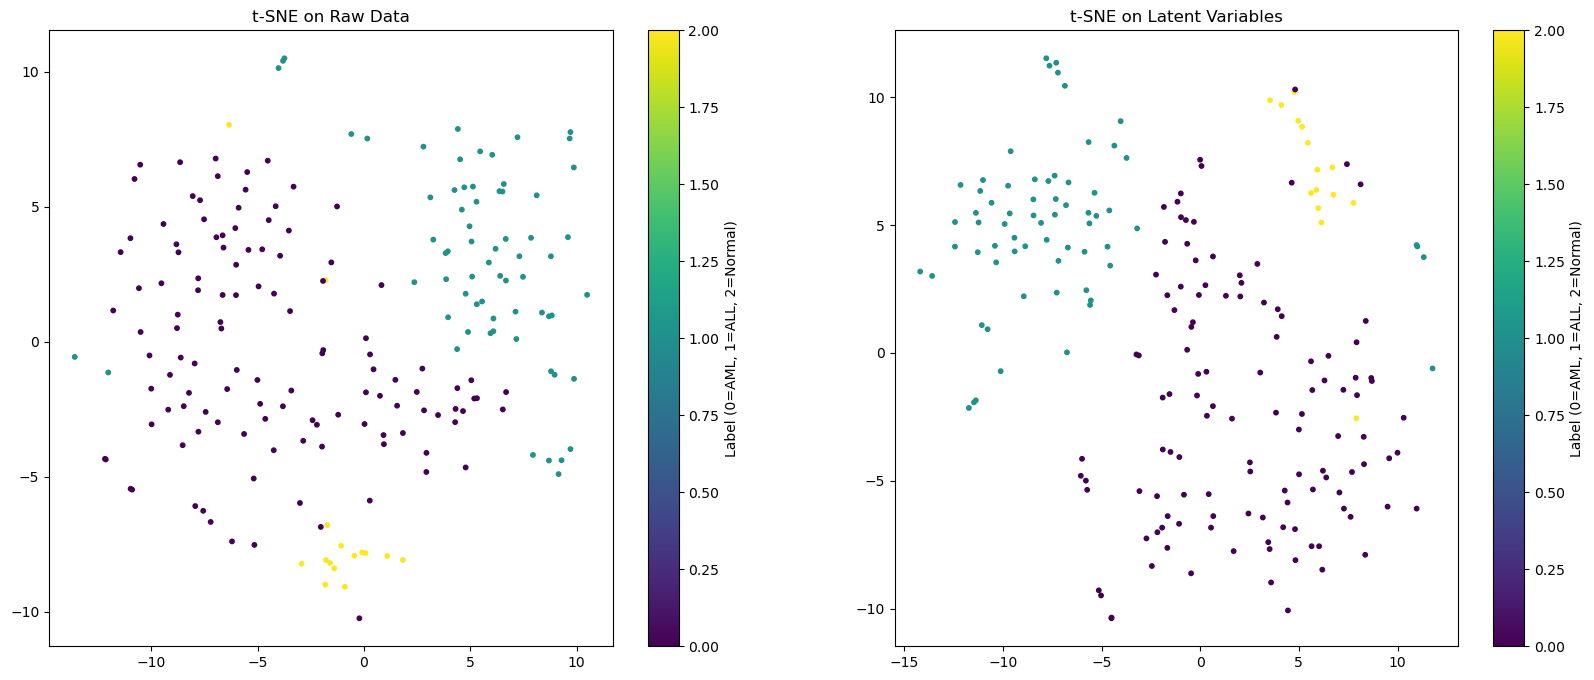

In [10]:
def TSNE_plots(z_loc, labels):
    raw_data_tsne = TSNE(n_components=2).fit_transform(X_norm)
    z_post_tsne = TSNE(n_components=2).fit_transform(z_loc.detach().cpu().numpy())

    plt.figure(figsize=(20, 8))
    plt.subplot(1, 2, 1)
    plt.scatter(raw_data_tsne[:, 0], raw_data_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Raw Data")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.subplot(1, 2, 2)
    plt.scatter(z_post_tsne[:, 0], z_post_tsne[:, 1], c=labels.flatten(), cmap='viridis', s=10)
    plt.title("t-SNE on Latent Variables")
    plt.colorbar(label='Label (0=AML, 1=ALL, 2=Normal)')
    plt.show()

z_loc = pyro.param("z_loc").detach()
TSNE_plots(z_loc, test_label)


In [ ]:
# --- assume your training SVI has run and ps is populated ---
ps       = pyro.get_param_store()
W_pm     = ps["w_loc"].detach()                    # [latent_dim, n_genes]
alpha_pm = (ps["alpha_a"] / ps["alpha_b"]).detach()# [latent_dim]
sigma_pm = ps["sigma_loc"].detach()                # scalar or [n_genes]
A_pm     = ps["A_loc"].detach()                    # [n_classes, latent_dim]
b_pm     = ps["b_loc"].detach()                    # [n_classes]

latent_dim = W_pm.shape[0]

# --- 1) Unsupervised PPCA “model” that only generates X under locked params ---
def infer_z_val_model(X):
    with pyro.plate("data", X.shape[0]):
        # ARD‐scaled prior on z
        z = pyro.sample(
            "z",
            dist.Normal(
                torch.zeros(latent_dim),                     # mean
                alpha_pm.sqrt().reciprocal()                 # std = 1/√α
            ).to_event(1)
        )
        # likelihood for X under fixed W, sigma
        x_loc = torch.matmul(z, W_pm)                     # [N_val, n_genes]
        pyro.sample(
            "x",
            dist.Normal(x_loc, sigma_pm).to_event(1),
            obs=X
        )

# --- 2) Guide that only learns z_loc_val / z_scale_val ---
def infer_z_val_guide(X):
    N, _ = X.shape
    z_loc   = pyro.param("z_loc_val", torch.randn(N, latent_dim))
    z_scale = pyro.param(
        "z_scale_val",
        torch.ones(N, latent_dim),
        constraint=dist.constraints.positive
    )
    with pyro.plate("data", N):
        pyro.sample("z", dist.Normal(z_loc, z_scale).to_event(1))

# --- 3) Run SVI on X only to infer z_loc_val / z_scale_val ---
# (do NOT clear the ParamStore here if you want to keep W_pm etc.)
optimizer_inf = ClippedAdam({"lr": 0.01})
svi_inf       = SVI(infer_z_val_model, infer_z_val_guide, optimizer_inf, loss=Trace_ELBO())

start = time.time()
n_steps = 5000
for step in range(n_steps):
    loss = svi_inf.step(X_val_tensor)
    if step % 300 == 0:
        print(f"[val step {step}] loss = {loss:.1f}")
print(f"Inference took {time.time() - start:.1f}s")


[val step 0] loss = 1590868.7
[val step 300] loss = 129273.6
[val step 600] loss = 96957.6
[val step 900] loss = 96048.5
[val step 1200] loss = 95976.0
[val step 1500] loss = 95970.3
[val step 1800] loss = 95954.3
[val step 2100] loss = 95994.4
[val step 2400] loss = 95956.4
[val step 2700] loss = 95970.6
[val step 3000] loss = 95962.0
[val step 3300] loss = 95964.2
[val step 3600] loss = 95975.6
[val step 3900] loss = 95965.5
[val step 4200] loss = 95963.1
[val step 4500] loss = 95985.0
[val step 4800] loss = 95961.6
Inference took 17.1s


Validation Accuracy: 0.9350


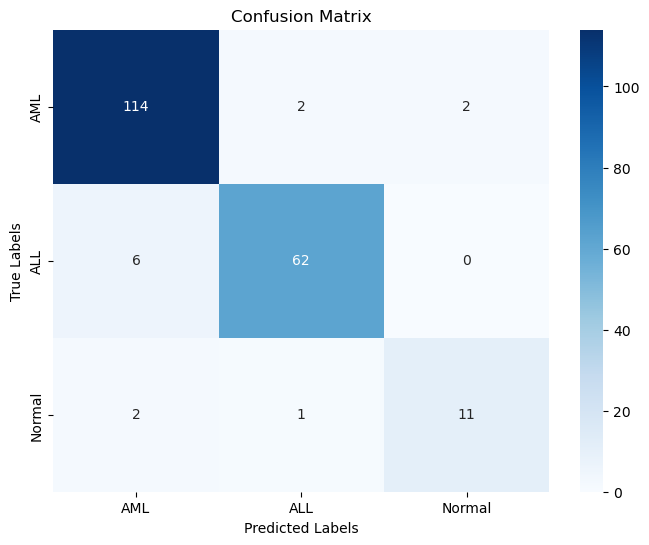

In [ ]:
# --- 4) Extract your inferred latent means ---
z_loc_val = pyro.param("z_loc_val").detach()   # [n_val_samples, latent_dim]

# --- 5) Prediction function ---
def predict_classes(z_loc, A, b, y_true):
    # Compute logits and probabilities
    logits = torch.matmul(z_loc, A.T) + b
    probs  = torch.softmax(logits, dim=-1)
    y_hat  = torch.argmax(probs, dim=-1).cpu().numpy()

    # Compute accuracy
    y_true = np.array(y_true).flatten()
    accuracy = (y_true == y_hat).mean()
    print(f"Validation Accuracy: {accuracy:.4f}")

    # Confusion matrix
    conf_matrix = confusion_matrix(y_true, y_hat)
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["AML", "ALL", "Normal"],
        yticklabels=["AML", "ALL", "Normal"]
    )
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix")
    plt.show()

    return y_hat

# --- 6) Call prediction with correct params ---
y_hat_val = predict_classes(z_loc_val, A_pm, b_pm, val_label)


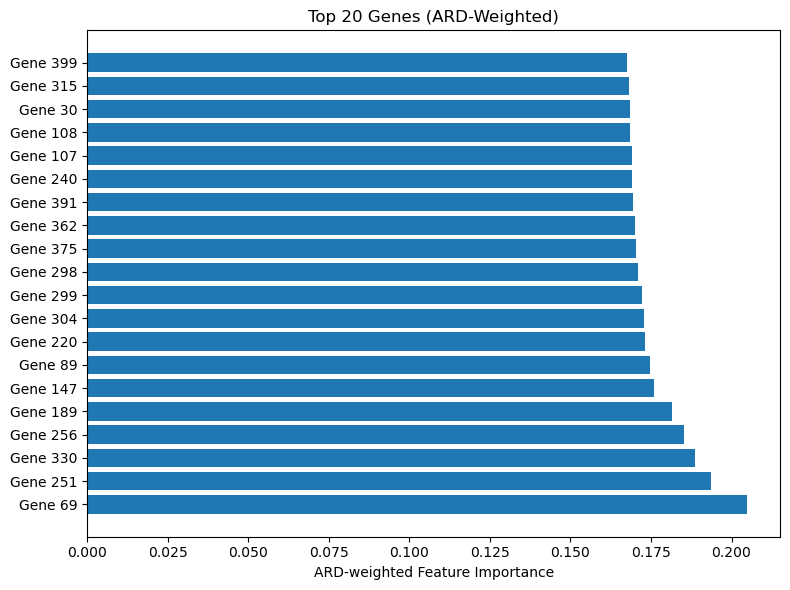

In [13]:
def compute_feature_importance_ard(W_post, alpha_a, alpha_b, top_n=20):
    """
    Compute ARD-weighted feature importance.
    
    W_post:   np.array of shape [latent_dim, n_genes]
    alpha_a:  np.array of shape [latent_dim]
    alpha_b:  np.array of shape [latent_dim]
    top_n:    number of top genes to return
    Returns:
      top_indices: np.array of shape [top_n]
      top_importance: np.array of shape [top_n]
    """
    # posterior mean of ARD precisions
    alpha_mean = alpha_a / alpha_b               # [latent_dim]
    scale      = 1.0 / np.sqrt(alpha_mean)       # [latent_dim]
    W_weighted = W_post * scale[:, None]         # [latent_dim, n_genes]
    
    # feature scores (mean absolute weight)
    feature_importance = np.abs(W_weighted).mean(axis=0)  # [n_genes]
    
    # pick and sort top_n
    top_idx = np.argsort(feature_importance)[-top_n:]
    top_imp = feature_importance[top_idx]
    sorter  = np.argsort(top_imp)
    return top_idx[sorter], top_imp[sorter]

def plot_top_genes_ard(top_indices, top_importance, gene_names=None):
    """
    Plot horizontal bar chart of top ARD-weighted genes.
    
    top_indices:     array of gene indices
    top_importance:  array of importances (same order)
    gene_names:      optional list/array of all gene names
    """
    if gene_names is not None:
        labels = [gene_names[i] for i in top_indices]
    else:
        labels = [f"Gene {i}" for i in top_indices]

    plt.figure(figsize=(8, max(4, len(top_indices) * 0.3)))
    plt.barh(labels, top_importance)
    plt.xlabel("ARD-weighted Feature Importance")
    plt.title(f"Top {len(top_indices)} Genes (ARD-Weighted)")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

# --- Example Usage ---
ps      = pyro.get_param_store()
W_post  = ps["w_loc"].detach().cpu().numpy()    # [latent_dim, n_genes]
alpha_a = ps["alpha_a"].detach().cpu().numpy()  # [latent_dim]
alpha_b = ps["alpha_b"].detach().cpu().numpy()  # [latent_dim]

top_n         = 20
top_idx, top_imp = compute_feature_importance_ard(W_post, alpha_a, alpha_b, top_n=top_n)
plot_top_genes_ard(top_idx, top_imp, gene_names=None)
